In [234]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline


from pathlib import Path

In [28]:
DATA = Path('..') / 'data'
df = pd.read_csv(DATA / "AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# 1. Inspeccion minima (pre-split)

Solo lo necesario para decidir como splitear: estructura, nulos y la
distribucion de `price` para elegir los bins de estratificacion.
El analisis real va despues del split, sobre el train set.

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [30]:
df.shape

(48895, 16)

In [31]:
df.isna().sum().sort_values(ascending=False)

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [32]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Vemos que hay precios iguales a 0 y tambien vemos en minimum_nights = 1250 lo cual son datos mal tomados directamente. Los puedo eliminar

### Que limpio antes del split y que no

**Antes del split** solo saco las filas con target invalido (`price == 0`):
una fila sin target no sirve ni para entrenar ni para evaluar.

**No** filtro `minimum_nights` aca. Es un outlier en un predictor, no en el
target: si lo saco de todo el dataset tambien lo saco del test, y el test
tiene que reflejar la realidad (en produccion van a llegar filas asi).
Ese tratamiento va dentro del pipeline, ajustado solo con train.

In [33]:
df_clean = df[df['price'] > 0]
df_clean.shape

(48884, 16)

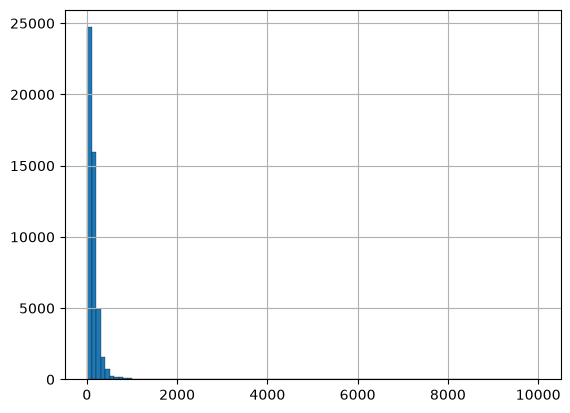

In [50]:
df_clean.price.hist(edgecolor='black', linewidth=0.2, bins=100)

plt.show()

### Estratificacion

Estratifico por `price` binneado, que es el target. Los cortes salen de los
cuantiles del describe (25% = 69, 50% = 106, 75% = 175) y quedan fijos:
no los ajusto mirando resultados.

`price_cat` se usa solo para repartir filas y se descarta enseguida — el
modelo nunca la ve.

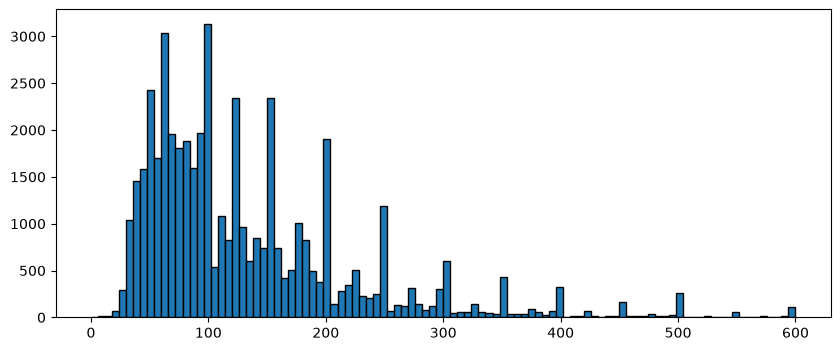

In [48]:
df_clean['price'].hist(bins=100, range=(0, 600), edgecolor='black', grid=False, figsize=(10, 4))
plt.show()

In [ ]:
# df['price_cat'] = pd.qcut(df['price'], q=5, labels=[1, 2, 3, 4, 5]) # queda la data perfectamente distribuida. Es menos interpretable igualmente

df_clean['price_cat'] = pd.cut(
    df_clean['price'],
    bins=[0, 60, 100, 150, 250, np.inf],
    labels=[1, 2, 3, 4, 5],
)

df_clean['price_cat'].value_counts().sort_index()

price_cat
1    10052
2    13865
3    10029
4     9730
5     5208
Name: count, dtype: int64

# 2. Train y Test set

In [52]:
train_set, test_set = train_test_split(
    df_clean, test_size=0.2, stratify=df_clean['price_cat'], random_state=42
)

train_set.shape, test_set.shape

((39107, 17), (9777, 17))

Comparo las proporciones para confirmar que el split respeto la distribucion,
y recien despues descarto `price_cat`.

In [53]:
pd.DataFrame({
    'full': df_clean['price_cat'].value_counts(normalize=True),
    'train': train_set['price_cat'].value_counts(normalize=True),
    'test': test_set['price_cat'].value_counts(normalize=True),
}).sort_index()

,full,train,test
price_cat,,,
1,0.205630,0.205641,0.205585
2,0.283631,0.283632,0.283625
3,0.205159,0.205155,0.205175
4,0.199043,0.199044,0.199039
5,0.106538,0.106528,0.106577


In [54]:
for s in (train_set, test_set):
    s.drop(columns='price_cat', inplace=True)

# 3. Explorar y Visualizar la data

De aca en adelante todo se hace sobre `deptos` (copia del train set).
El test set no se vuelve a tocar hasta la evaluacion final.

In [55]:
deptos = train_set.copy()

In [56]:
deptos.shape

(39107, 16)

In [57]:
deptos.isna().sum().sort_values(ascending=False).head(4)

last_review          7974
reviews_per_month    7974
host_name              17
name                   14
dtype: int64

### Distribuciones

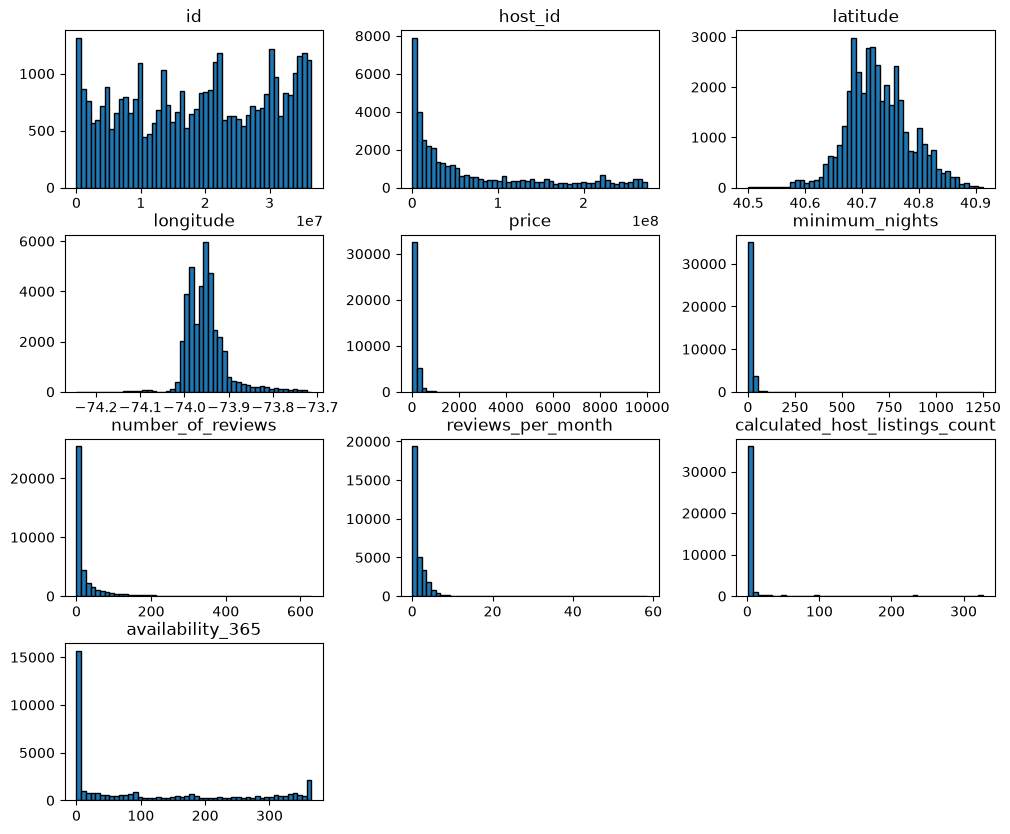

In [58]:
deptos.hist(edgecolor='black', bins=50, grid=False, figsize=(12,10))
plt.show()

En muchas features se pueden ver la presencia de outliers, por eso son tan asimetricas los histogramas y ademas aparece un rango bastante amplio que parece que no tienen valores que caigan en esos rangos

In [59]:
deptos['room_type'].value_counts()

room_type
Entire home/apt    20363
Private room       17835
Shared room          909
Name: count, dtype: int64

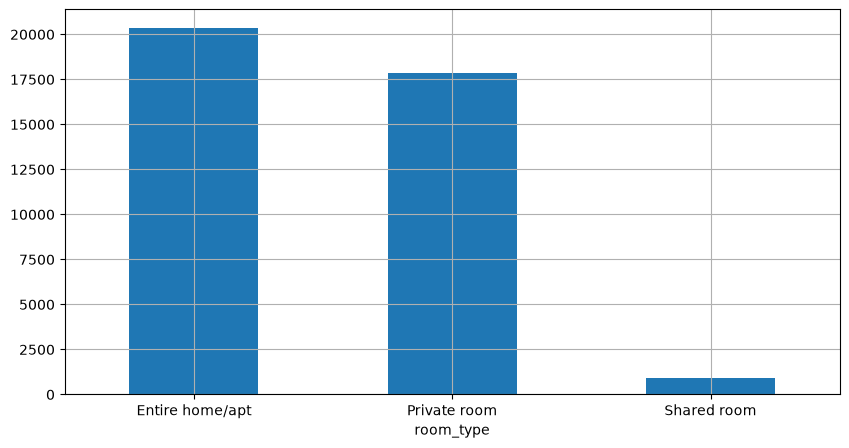

In [60]:
deptos['room_type'].value_counts().sort_index().plot(kind='bar', grid=True, figsize=(10,5), rot=0)
plt.show()

In [61]:
deptos['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        17368
Brooklyn         16015
Queens            4544
Bronx              880
Staten Island      300
Name: count, dtype: int64

In [62]:
deptos.host_id.value_counts()

host_id
219517861    259
107434423    176
30283594      99
137358866     83
12243051      78
            ... 
61303786       1
50045329       1
32715865       1
152177080      1
3130728        1
Name: count, Length: 30877, dtype: int64

In [63]:
deptos.host_name.value_counts()

host_name
Michael         333
David           314
Sonder (NYC)    259
John            235
Alex            233
               ... 
Luz Dary          1
Malu              1
Mymy              1
孙浩                1
James &           1
Name: count, Length: 10007, dtype: int64

### Price por categoria

In [64]:
deptos.groupby(by='neighbourhood_group')['price'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

,mean,median,std
neighbourhood_group,,,
Manhattan,197.180101,150.0,298.258473
Brooklyn,124.573525,90.0,195.388941
Staten Island,110.983333,75.0,291.450122
Queens,100.081206,75.0,178.458664
Bronx,88.501136,65.0,113.390011


In [65]:
deptos.groupby(by='room_type')['price'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

,mean,median,std
room_type,,,
Entire home/apt,211.554879,160.0,290.150120
Private room,90.391646,70.0,172.448563
Shared room,72.152915,45.0,111.041385


Pueden presentar tanta varianza debido a que no es lo mismo un departamento/casa entera en Manhattan que en el Bronx

In [66]:
deptos.groupby(['room_type', 'neighbourhood_group'])['price'].agg(['mean', 'median', 'std'])

mean  median         std
room_type       neighbourhood_group                                
Entire home/apt Bronx                130.026316   100.0   98.730152
                Brooklyn             178.457585   145.0  235.897322
                Manhattan            248.725625   190.0  337.316452
                Queens               146.846655   120.0  120.657012
                Staten Island        162.135135   100.0  407.942484
Private room    Bronx                 66.737643    53.0  115.012544
                Brooklyn              76.518523    65.0  133.319067
                Manhattan            118.109565    90.0  202.947389
                Queens                72.302671    59.0  200.721290
                Staten Island         61.506944    51.0   32.834400
Shared room     Bronx                 64.980000    42.5  110.876377
                Brooklyn              51.634069    35.0   58.733402
                Manhattan             89.896000    69.0   97.836119
                Queens                74.320755    38.0  189.108345
                Staten Island         55.250000    30.0   47.718670

In [67]:
pivot = deptos.pivot_table(values='price', index='neighbourhood_group', columns='room_type', aggfunc=['mean', 'median', 'std'])

pivot

mean                                   median  \
room_type           Entire home/apt Private room Shared room Entire home/apt   
neighbourhood_group                                                            
Bronx                    130.026316    66.737643   64.980000           100.0   
Brooklyn                 178.457585    76.518523   51.634069           145.0   
Manhattan                248.725625   118.109565   89.896000           190.0   
Queens                   146.846655    72.302671   74.320755           120.0   
Staten Island            162.135135    61.506944   55.250000           100.0   

                                                         std               \
room_type           Private room Shared room Entire home/apt Private room   
neighbourhood_group                                                         
Bronx                       53.0        42.5       98.730152   115.012544   
Brooklyn                    65.0        35.0      235.897322   133.319067   
Manhattan                   90.0        69.0      337.316452   202.947389   
Queens                      59.0        38.0      120.657012   200.721290   
Staten Island               51.0        30.0      407.942484    32.834400   

                                 
room_type           Shared room  
neighbourhood_group              
Bronx                110.876377  
Brooklyn              58.733402  
Manhattan             97.836119  
Queens               189.108345  
Staten Island         47.718670

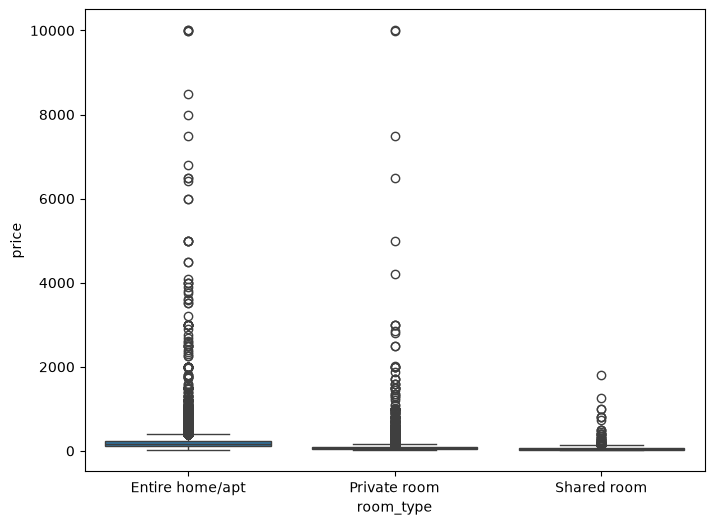

In [68]:
plt.figure(figsize=(8,6))
sns.boxplot(data=deptos, x='room_type', y='price')

plt.show()


### Geografia

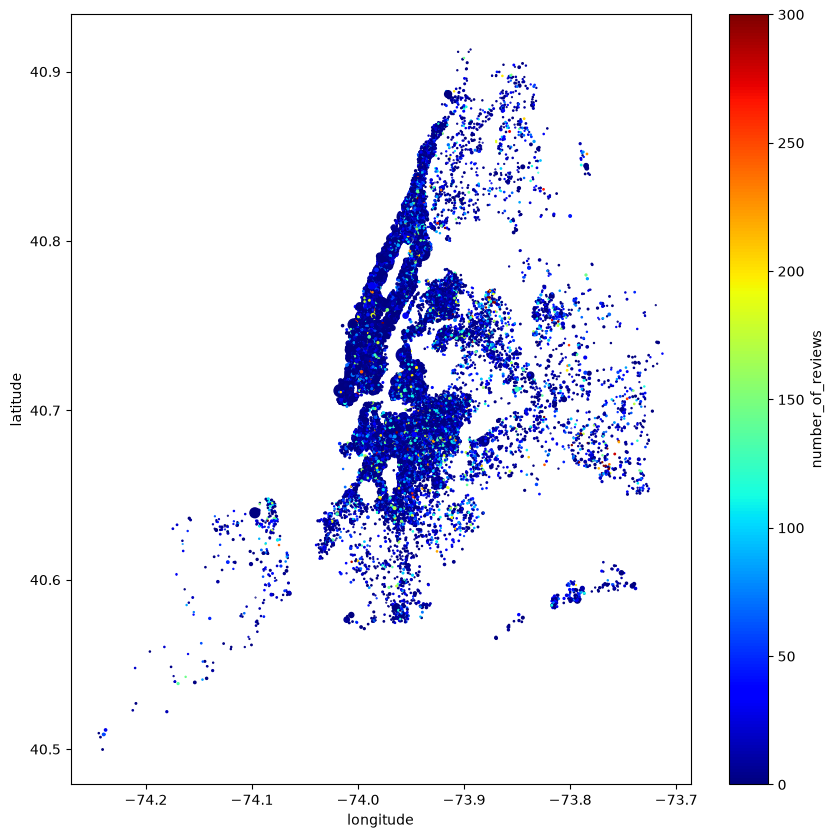

In [78]:
deptos.plot(kind='scatter', x='longitude', y='latitude', c='number_of_reviews', s=deptos['price']/100, cmap='jet', figsize=(10,10), vmax=300)

plt.show()

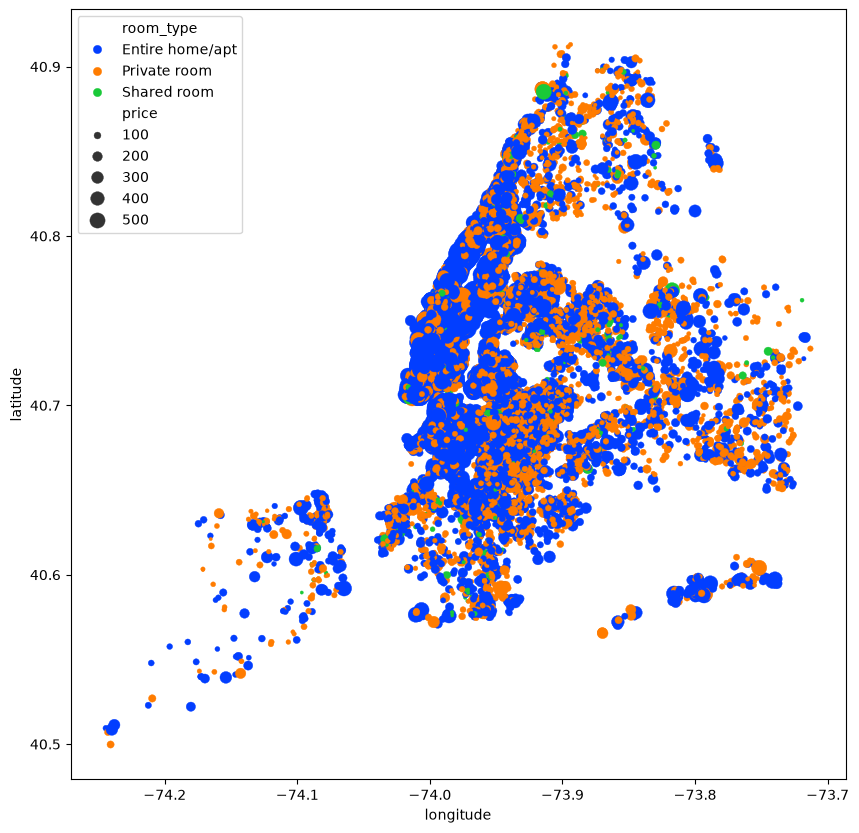

In [110]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=deptos, x='longitude', y='latitude',
                hue='room_type', size=deptos['price'].clip(upper=500),
                sizes=(3, 120), alpha=1, edgecolor=None, palette='bright')
#plt.legend(title='room_type', markerscale=1.5)
plt.show()


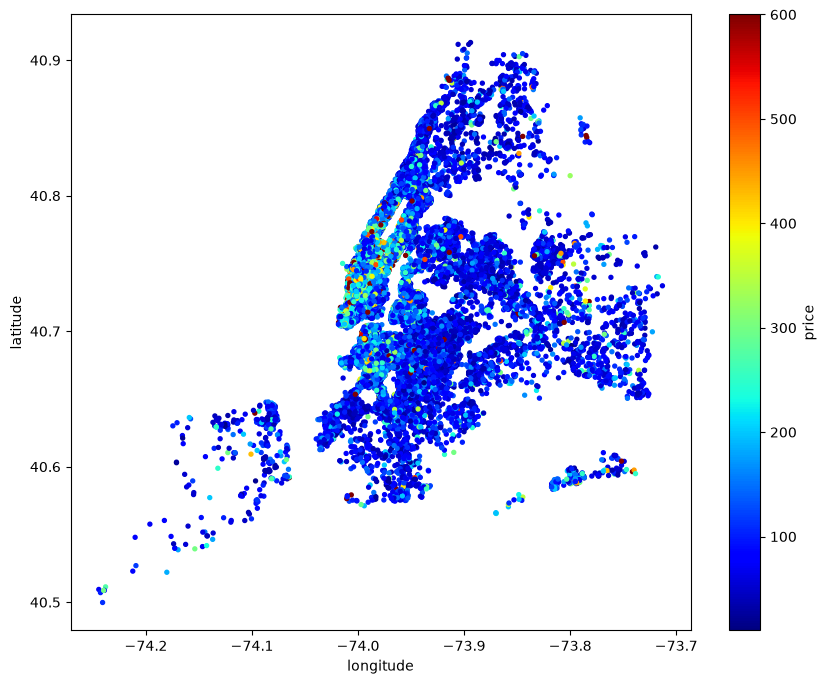

In [91]:
deptos.plot(kind='scatter', x='longitude', y='latitude', c='price', figsize=(10,8), cmap='jet', alpha=1, s=8, vmax=600)

plt.show()

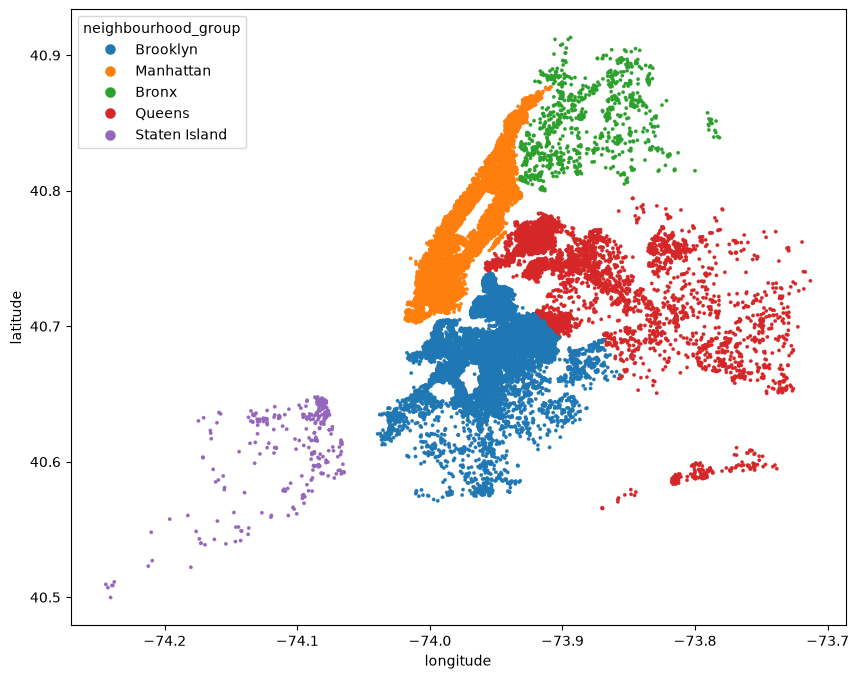

In [90]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=deptos, x='longitude', y='latitude',
                hue='neighbourhood_group', s=6, alpha=1,
                edgecolor=None, palette='tab10')
plt.legend(title='neighbourhood_group', markerscale=3)
plt.show()


* Veo claramente que el numero de reviews no afecta (tanto por lo menos) el precio como pense en primera instancia. Los puntos mas grandes (mayor precio) no tienen tantas reviews (color mas azulados)
* Lo que mas afecta claramente es el barrio donde estan y si el tipo de casa que sea.

### Correlaciones

In [79]:
deptos.info()

<class 'pandas.DataFrame'>
Index: 39107 entries, 26291 to 4199
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              39107 non-null  int64  
 1   name                            39093 non-null  str    
 2   host_id                         39107 non-null  int64  
 3   host_name                       39090 non-null  str    
 4   neighbourhood_group             39107 non-null  str    
 5   neighbourhood                   39107 non-null  str    
 6   latitude                        39107 non-null  float64
 7   longitude                       39107 non-null  float64
 8   room_type                       39107 non-null  str    
 9   price                           39107 non-null  int64  
 10  minimum_nights                  39107 non-null  int64  
 11  number_of_reviews               39107 non-null  int64  
 12  last_review                     31133 non-nul

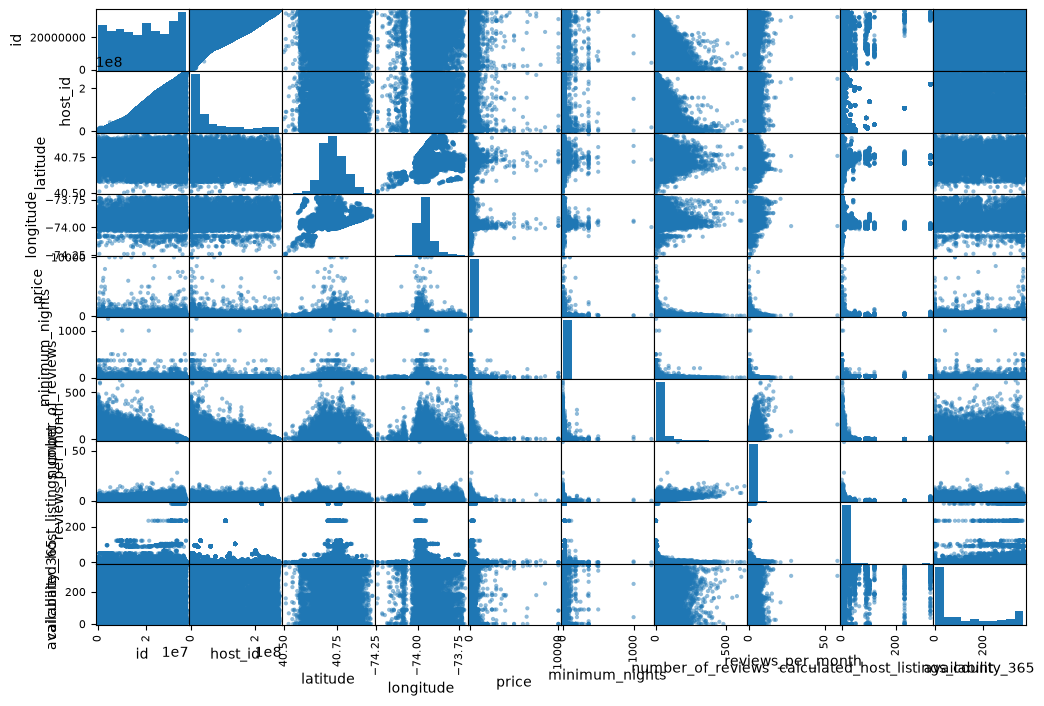

In [81]:
scatter_matrix(deptos.select_dtypes('number'), figsize=(12, 8))
  
plt.show()

In [80]:
corr_matrix = deptos.select_dtypes('number').corr()
corr_matrix['price'].sort_values(ascending=False)

price                             1.000000
availability_365                  0.078338
calculated_host_listings_count    0.054431
minimum_nights                    0.046618
latitude                          0.033156
host_id                           0.013512
id                                0.007524
reviews_per_month                -0.032547
number_of_reviews                -0.047771
longitude                        -0.145718
Name: price, dtype: float64

* Vemos que las correlaciones con las features numericas son bajas, y como ya vimos anteriormente, hay mucho mas correlacion con el room_type y neighbourdhood_group.

# Preparar la data para ML

* Tengo que limpiar la data primero

In [113]:
deptos = train_set.drop(columns='price')
deptos_labels = train_set['price'].copy()

In [115]:
deptos.isna().sum().sort_values(ascending=False).head(4)

reviews_per_month    7974
last_review          7974
host_name              17
name                   14
dtype: int64

In [119]:
deptos[deptos['number_of_reviews'] == 0].shape

(7974, 15)

* Los NaN en reviews y last_review vienen de que airbnb que no tienen un number_of_reviews = 0

In [122]:
imputer = SimpleImputer(strategy='constant', fill_value=0)
deptos['reviews_per_month'] = imputer.fit_transform(deptos[['reviews_per_month']])

In [126]:
deptos['reviews_per_month'].isna().sum()

np.int64(0)

* No le encuentro uso a last_reviewed asi que voy a crear otra feature que quizas tengo mejor uso

In [140]:
deptos['never_reviewed'] = deptos['last_review'].isna().astype(int)


In [141]:
deptos = deptos.drop(columns='last_review')
deptos.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365', 'never_reviewed'],
      dtype='str')

In [144]:
deptos[deptos['reviews_per_month'] == 0].head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,never_reviewed
42191,32749511,Cozy furnished 2 Bedroom (30 day minimum),246290852,Eddie,Brooklyn,Bedford-Stuyvesant,40.69239,-73.94884,Entire home/apt,28,0,0.0,2,264,1
29886,23003201,South slope Brooklyn 1private bedroom!,170629692,Chris,Brooklyn,Sunset Park,40.66182,-73.99387,Private room,1,0,0.0,1,0,1
41274,32125944,Perfect East Village Loft,238779678,Dustin,Manhattan,East Village,40.72764,-73.99060,Private room,30,0,0.0,9,343,1
9400,7205668,Sunny room in GPoint/Williamsburg,25712247,Alyssa,Brooklyn,Greenpoint,40.72283,-73.95232,Private room,1,0,0.0,1,0,1
10788,8304576,Beautiful studio in FIDI,14386700,Elsa,Manhattan,Financial District,40.70698,-74.01383,Entire home/apt,10,0,0.0,1,0,1


In [147]:
deptos.isna().sum().sort_values(ascending=False).head(2)

host_name    17
name         14
dtype: int64

In [154]:
deptos.host_name.nunique()

10007

* QUE HAGO CON HOST_NAME Y NAME? los tiro. Pueden aportar poco

In [ ]:
deptos = deptos.drop(columns=['host_name', 'name', 'host_id', 'id'])
deptos.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365', 'never_reviewed'],
      dtype='str')

In [168]:
frecuencia_barrios = deptos['neighbourhood'].value_counts()
frecuentes = frecuencia_barrios[frecuencia_barrios >= 50].index
print(f'Barrios que quedan: {len(frecuentes)} de {len(frecuencia_barrios)}')

Barrios que quedan: 89 de 217


* Siguen quedando muchisimos barrios. No se si es una buena opcion usar un one hot encoder.
* Para hacer que todos los barrios que no son frecuentes se llamen Other, ejecutar el codigo de abajo

In [ ]:
#deptos['neighbourhood'] = deptos['neighbourhood'].where(deptos['neighbourhood'].isin(frecuentes), 'Other')


In [171]:
deptos = deptos.drop(columns=['neighbourhood'])
deptos.columns

Index(['neighbourhood_group', 'latitude', 'longitude', 'room_type',
       'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365', 'never_reviewed'],
      dtype='str')

In [172]:
len(deptos.columns)

10

* Me quedo con 10 features en principio, se van a agregar algunas por el onehotencoder. Quizas tambien borre otras.
* Habia una fila donde minimum_nights == 1250, elimino esa fila abajo.

In [173]:
deptos = deptos[deptos['minimum_nights'] <= 365]

* Este dato availability_365 es raro. Hay muchos que tienen 0 dias disponibles y otros que tienen 365 o 364. No voy a hacer nada con esos datos pero se puede hacer algun tipo de flag.

In [175]:
deptos.availability_365.value_counts()

availability_365
0      14047
365     1019
364      396
1        311
89       288
       ...  
114       20
196       20
181       18
183       17
202       15
Name: count, Length: 366, dtype: int64

* Sigo con el encoding de las features categoricas.

In [178]:
deptos[['neighbourhood_group', 'room_type']]

,neighbourhood_group,room_type
26291,Brooklyn,Entire home/apt
24741,Brooklyn,Private room
20415,Brooklyn,Entire home/apt
42191,Brooklyn,Entire home/apt
18753,Manhattan,Private room
...,...,...
42078,Manhattan,Private room
12608,Brooklyn,Entire home/apt
8360,Manhattan,Entire home/apt
26513,Queens,Private room


In [185]:
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = cat_encoder.fit_transform(deptos[['neighbourhood_group', 'room_type']])

In [186]:
df_encoded = pd.DataFrame(
    encoded,
    columns=cat_encoder.get_feature_names_out(['neighbourhood_group', 'room_type']),
    index=deptos.index
)

deptos_encoded = pd.concat([deptos.drop(columns=['neighbourhood_group', 'room_type']), df_encoded], axis=1) 

* deptos_encoded es el dataframe modificado con el OneHotEncoder

In [187]:
deptos_encoded

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,never_reviewed,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
26291,40.69563,-73.97051,3,53,2.50,1,75,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
24741,40.71729,-73.94530,3,1,0.04,1,67,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
20415,40.68164,-73.97790,3,22,0.72,2,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
42191,40.69239,-73.94884,28,0,0.00,2,264,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
18753,40.76749,-73.95471,4,101,2.94,1,49,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42078,40.75803,-73.98887,1,6,2.61,9,289,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
12608,40.61860,-74.00710,3,52,1.20,1,291,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
8360,40.79169,-73.97498,1,5,0.13,1,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
26513,40.77063,-73.87543,1,222,10.39,1,164,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


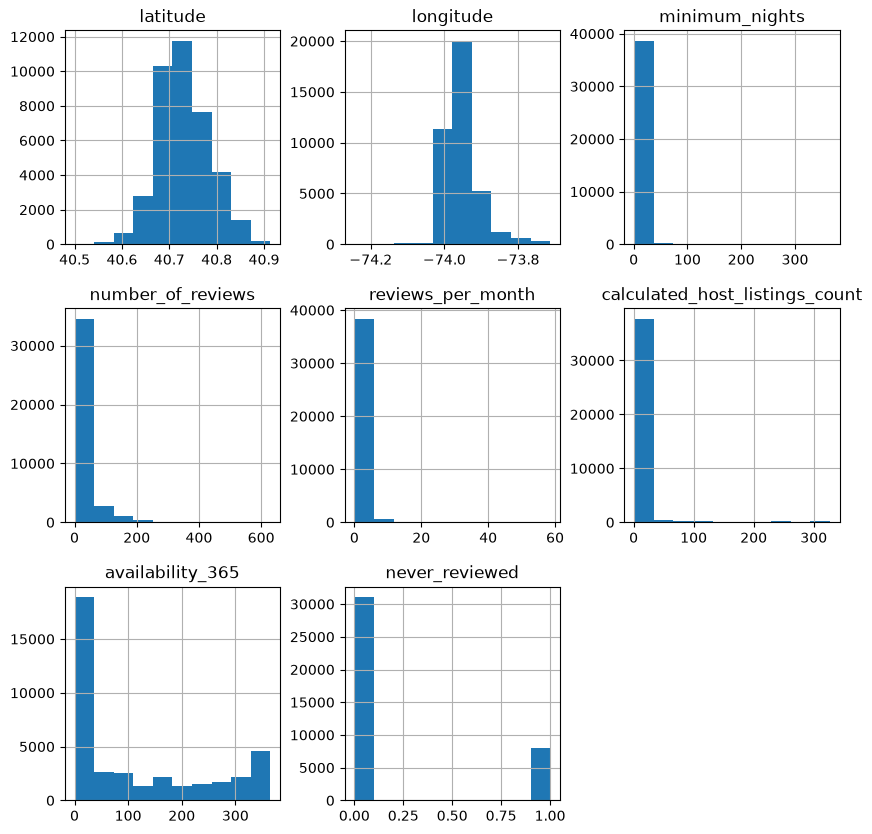

In [190]:
deptos.hist(figsize=(10,10))

plt.show()

* A minimum_nights lo tiraria. Lo vamos a dejar unicamente para ver como funciona de ultima despues lo tiro, para ver si mejora el modelo

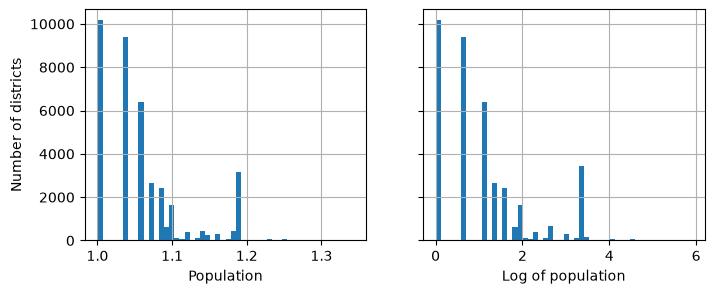

In [214]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
deptos["minimum_nights"].apply(lambda x: x**(1/20)).hist(ax=axs[0], bins=50)
deptos["minimum_nights"].apply(lambda x: np.log(x)).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

plt.show()

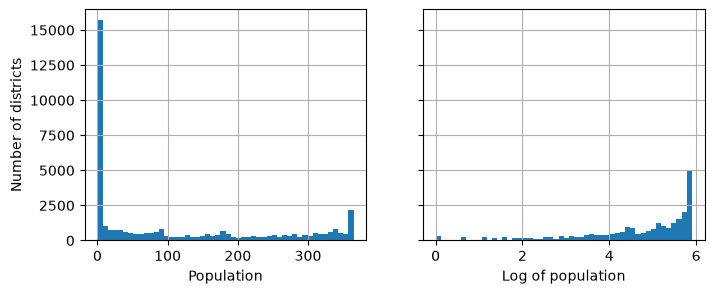

In [200]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
deptos["availability_365"].hist(ax=axs[0], bins=50)
deptos[deptos["availability_365"]>0]['availability_365'].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

plt.show()

### Custom Transformer

In [ ]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [229]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=400., random_state=42)
similarities = cluster_simil.fit_transform(deptos[["latitude", "longitude"]])

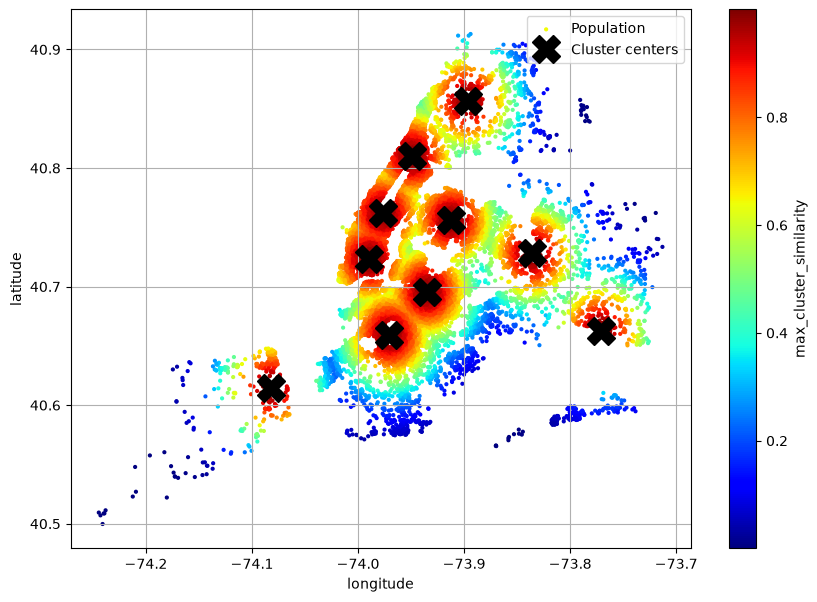

In [230]:
deptos_encoded["max_cluster_similarity"] = similarities.max(axis=1)

deptos_encoded.plot(kind="scatter", x="longitude", y="latitude", grid=True,
                     s= 4, label="Population",
                     c="max_cluster_similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")

plt.show()

### Empiezo con los pipelines

In [232]:
deptos_encoded.isna().sum().max()

np.int64(0)

* No tiene datos faltantes, bien.

* Quiero aplicar todos los cambios que ya hice, pero ahora utilizando un/varios pipeline. 

In [235]:
deptos.columns

Index(['neighbourhood_group', 'latitude', 'longitude', 'room_type',
       'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365', 'never_reviewed'],
      dtype='str')

In [237]:
train_set.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

Lista de transformaciones que les hice a las features:
* FEATURES CATEGORICAS:
* las observaciones con numbers_of_reviews 0 tienen last_review y reviews_per_month igual a 0, por eso impute los NaN de review_per_month a 0
* a last_review la transforme en never_reviewed (1 si tenian NaN, 0 si no)
* utilice el one hot encoder para neighbourhood_group y room_type
* borre id, name, host_id, host_name, neighbourhood
* FEATURES NUMERICAS:
* aplicar logaritmo1p y estandarizar todas las variables.

In [236]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

cat_attribs = ['neighbourhood_group', 'room_type']

In [ ]:
num_pipeline = make_pipeline()

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())